# Merge Catalogs: NCS + USGS + ISC-GEM — v8
## Indian Plate Seismogenic System (3–40°N, 60–100°E)

## Input files verified (April 2026)

| Source | File(s) | Events | Time range | Notes |
|--------|---------|--------|------------|-------|
| NCS | `NCS_data.xlsx` | 4,402 | 2019-08-01 – 2026-04-03 | UTC; CUSTOM box 3–40°N, 60–100°E; depth 0–70 km; M≥3.5 at download. Includes 1,061 Hindu Kush + 44 Makran NCS events. |
| USGS | `query1.csv` + `query2.csv` | 7,677 + 16,684 = 24,361 raw; 24,078 unique IDs | 1960-01-07 – 2026-04-03 | Split at year 2000; 283 duplicate events in overlap deduped by ID |
| ISC-GEM main | `isc-gem-cat.csv` | 74,159 | 1904-04-04 – 2021-12-31 | v12.1; already Mw homogenised |
| ISC-GEM suppl | `isc-gem-suppl.csv` | 3,788 with Mw | 1904-01-20 – 2021-08-12 | 6,046 no Mw dropped |

## Changes v7 → v8

| # | Change |
|---|--------|
| 1 | `assign_zone()` rewritten — zero coverage gaps verified across full 3–40°N, 60–100°E grid |
| 2 | NE_India boundary: lon ≥ 88°E (was 88°E, unchanged) but lat floor 20°N (was 20°N); now explicit |
| 3 | Andaman_Nicobar: south boundary extended to 3°N (was 3°N, now consistent with Makran) |
| 4 | Makran: south boundary extended to 3°N (covers offshore Arabian Sea western seismicity) |
| 5 | Peninsular_Shield: covers all remaining points including Arabian Sea and Bay of Bengal offshore |
| 6 | b-value σ display precision improved: 4 decimal places (was 3, showed 0.000 for some zones) |
| 7 | `pre2010_sparse` extended to include Makran (low historical coverage before 2010) |

## Five seismotectonic zones

| Zone | Tectonic setting | Key references |
|------|-----------------|----------------|
| Himalaya_HinduKush | Continental collision + Hindu Kush intraslab | Bilham et al. 2001; Seeber & Armbruster 1981 |
| NE_India | Arcuate belt + Shillong Plateau intraplate | Kayal 2008 |
| Andaman_Nicobar | Oceanic subduction (2004 Mw 9.1 source zone) | Engdahl et al. 1998 |
| Makran | Arabian Sea subduction, tsunami source | Byrne et al. 1992 |
| Peninsular_Shield | Stable craton, intraplate (1993 Killari, 2001 Bhuj) | Sitharam & Kolathayar 2013 |

## Merge rules (unchanged)
- Priority: NCS > ISC-GEM > USGS
- Dedup: Δtime ≤ 60 s AND equirectangular distance ≤ 30 km
- All times UTC tz-naive.


## 0) Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

try:
    from IPython.display import display
except ImportError:
    display = print

# ── File paths ────────────────────────────────────────────────────────────────
NCS_FILE       = '/content/NCS_data.xlsx'  # CUSTOM box 3-40N 60-100E, depth 0-70km, M>=3.5, UTC
USGS_FILE1     = '/content/query1.csv'    # 1960-01-07 – 2000-12-29
USGS_FILE2     = '/content/query2.csv'    # 2000-01-01 – 2026-04-03  (283 events overlap with FILE1)
ISC_FILE       = '/content/isc-gem-cat.csv'
ISC_SUPPL_FILE = '/content/isc-gem-suppl.csv'

# ── Study region — Indian Plate seismogenic system ────────────────────────────
LAT_MIN, LAT_MAX = 3.0, 40.0
LON_MIN, LON_MAX = 60.0, 100.0
DEPTH_MAX        = 70.0
MAG_MIN          = 4.0

# ── Deduplication ─────────────────────────────────────────────────────────────
DEDUP_TIME_S  = 60
DEDUP_DIST_KM = 30.0

# ── Quality-flag thresholds ───────────────────────────────────────────────────
FIXED_DEPTHS    = {10.0, 15.0, 33.0, 35.0}
HEAPING_BAND_LO = 4.75
HEAPING_BAND_HI = 5.25

# ── NCS magnitude threshold ───────────────────────────────────────────────────
NCS_ML_THRESHOLD = 5.0

# ── ISC-GEM coverage ──────────────────────────────────────────────────────────
ISC_GEM_END = pd.Timestamp('2021-12-31')

# ── Five seismotectonic zones ─────────────────────────────────────────────────
ZONES = ['Himalaya_HinduKush', 'NE_India', 'Andaman_Nicobar',
         'Makran', 'Peninsular_Shield']

# ── Priority ──────────────────────────────────────────────────────────────────
SOURCE_PRIORITY = {'NCS': 0, 'ISC-GEM': 1, 'USGS': 2}

os.makedirs('results_figures', exist_ok=True)
print('Configuration loaded — Indian Plate Seismogenic System')
print(f'  Region     : {LAT_MIN}–{LAT_MAX}°N, {LON_MIN}–{LON_MAX}°E')
print(f'  Depth      : ≤{DEPTH_MAX} km')
print(f'  Mag min    : ≥{MAG_MIN}')
print(f'  Dedup      : ≤{DEDUP_TIME_S} s + ≤{DEDUP_DIST_KM} km')
print(f'  Zones      : {ZONES}')


Configuration loaded — Indian Plate Seismogenic System
  Region     : 3.0–40.0°N, 60.0–100.0°E
  Depth      : ≤70.0 km
  Mag min    : ≥4.0
  Dedup      : ≤60 s + ≤30.0 km
  Zones      : ['Himalaya_HinduKush', 'NE_India', 'Andaman_Nicobar', 'Makran', 'Peninsular_Shield']


## 1) Magnitude homogenisation (vectorised)

USGS reports mixed types; NCS reports no type (Ml for M<5, Mw for M≥5 by convention).
All converted to Mw using Scordilis (2006).

**Conversions applied:**
- `mb` → Mw: `0.85 × mb + 1.03`  (valid mb ≤ 6.2; capped)
- `ms` (≤ 6.1) → Mw: `0.67 × ms + 2.07`
- `ms` (> 6.1) → Mw: `0.99 × ms + 0.08`
- `ml` / `md` / `mblg` → Mw: `0.67 × ml + 1.60`
- NCS M < 5.0 assigned `ml`, then converted via same Ml formula
- Already-Mw types (`mw`, `mwc`, `mww`, `mwb`, `mwr`, `mwp`, `w`, `mwmwp`) — identity


In [2]:
def vectorised_mw_conversion(magnitude: pd.Series, mag_type: pd.Series):
    """
    Vectorised Mw conversion (Scordilis 2006, BSSA 96:2311).
    Returns (mw_series, was_converted_series).
    Conditions checked in priority order with np.select.
    """
    mt = mag_type.str.lower().str.strip()

    already_mw = mt.isin(['mw','mwc','mww','mwb','mwr','mwp','w','mwmwp'])

    is_mb = mt == 'mb'
    is_ms = mt.isin(['ms','mss','mszh'])
    is_ml = mt.isin(['ml','md','mblg'])

    mb_val = magnitude.clip(upper=6.2)   # cap at validity ceiling

    conds = [already_mw, is_mb, is_ms & (magnitude <= 6.1), is_ms, is_ml]
    vals  = [
        magnitude,
        (0.85 * mb_val + 1.03).round(2),
        (0.67 * magnitude + 2.07).round(2),
        (0.99 * magnitude + 0.08).round(2),
        (0.67 * magnitude + 1.60).round(2),
    ]
    mw_out = pd.Series(np.select(conds, vals, default=magnitude.values),
                       index=magnitude.index, dtype=float)
    converted = ~already_mw & (is_mb | is_ms | is_ml)
    return mw_out, converted


def apply_mag_conversion(df: pd.DataFrame) -> pd.DataFrame:
    """Keep originals, replace magnitude column with Mw equivalent."""
    df = df.copy()
    df['magnitude_orig'] = df['magnitude']
    df['mag_type_orig']  = df['mag_type']
    mw, conv = vectorised_mw_conversion(df['magnitude'], df['mag_type'])
    df['magnitude']     = mw
    df['was_converted'] = conv
    df['mag_type']      = 'Mw'
    return df


# Sanity check — includes NCS Ml case
print(f'  {"Type":<6} {"Orig":>6} → {"Mw":>6}  Converted')
for mt, val in [('mb',4.5),('mb',5.0),('mb',6.0),
                ('ms',5.0),('ms',7.0),
                ('ml',4.2),('ml',4.8),   # NCS-style Ml events
                ('Mw',5.5)]:
    mw_s, conv_s = vectorised_mw_conversion(pd.Series([val]), pd.Series([mt]))
    print(f'  {mt:<6} {val:>6.1f} → {mw_s.iloc[0]:>6.2f}  {conv_s.iloc[0]}')


  Type     Orig →     Mw  Converted
  mb        4.5 →   4.85  True
  mb        5.0 →   5.28  True
  mb        6.0 →   6.13  True
  ms        5.0 →   5.42  True
  ms        7.0 →   7.01  True
  ml        4.2 →   4.41  True
  ml        4.8 →   4.82  True
  Mw        5.5 →   5.50  False


## 2) Load each catalog

In [3]:
# ── NCS — times are UTC (string suffix " UTC") ───────────────────────────────
# v4 fix: strip " UTC" not " IST"; no offset subtraction; result is tz-naive.
# v4 fix: NCS has no mag_type column. Convention from NCS website:
#   M < 5.0  → local magnitude (Ml) → apply Scordilis Ml→Mw conversion
#   M ≥ 5.0  → Mw (reported directly)

ncs_raw = pd.read_excel(NCS_FILE, sheet_name='Sheet1', header=1)

ncs = pd.DataFrame()
ncs['time'] = pd.to_datetime(
    ncs_raw['Origin Time'].astype(str)
        .str.replace(' UTC', '', regex=False).str.strip(),
    errors='coerce'
)   # already UTC, tz-naive — no offset subtraction needed

ncs['latitude']  = pd.to_numeric(ncs_raw['Lat'],       errors='coerce')
ncs['longitude'] = pd.to_numeric(ncs_raw['Long'],      errors='coerce')
ncs['depth_km']  = pd.to_numeric(ncs_raw['Depth'],     errors='coerce')
ncs['magnitude'] = pd.to_numeric(ncs_raw['Magnitude'], errors='coerce')

# Assign mag_type by threshold (NCS convention — no type column in file)
ncs['mag_type'] = np.where(ncs['magnitude'] < NCS_ML_THRESHOLD, 'ml', 'Mw')
ncs['source']   = 'NCS'

ncs = ncs.dropna(subset=['time','latitude','longitude','depth_km','magnitude'])

# Apply Ml→Mw conversion for NCS M < 5.0 events
ncs = apply_mag_conversion(ncs)

print(f'NCS: {len(ncs_raw)} raw → {len(ncs)} events (UTC)')
print(f'  Time   : {ncs.time.min()} → {ncs.time.max()}')
print(f'  Mag    : {ncs.magnitude.min():.2f} – {ncs.magnitude.max():.2f} (post-conversion Mw)')
print(f'  Ml→Mw  : {ncs.was_converted.sum()} events converted '
      f'({100*ncs.was_converted.mean():.1f}%)')
print(f'  Mw kept: {(~ncs.was_converted).sum()} events (M ≥ {NCS_ML_THRESHOLD})')


NCS: 4402 raw → 4402 events (UTC)
  Time   : 2019-08-01 00:43:21 → 2026-04-03 16:32:43
  Mag    : 3.94 – 7.50 (post-conversion Mw)
  Ml→Mw  : 4178 events converted (94.9%)
  Mw kept: 224 events (M ≥ 5.0)


In [4]:
# ── USGS — two files covering 1960–2026, overlap at year 2000 ────────────────
# query1.csv : 1960-01-07 – 2000-12-29  (7,677 events)
# query2.csv : 2000-01-01 – 2026-04-03  (16,684 events)
# Overlap    : 283 events in year 2000 — identical IDs in both files.
# Fix        : concatenate then drop duplicates by USGS event ID.

def _load_usgs(filepath):
    df = pd.read_csv(filepath)
    df['time'] = (pd.to_datetime(df['time'], errors='coerce', utc=True)
                    .dt.tz_localize(None))
    df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    df['depth_km']  = pd.to_numeric(df['depth'],     errors='coerce')
    df['magnitude'] = pd.to_numeric(df['mag'],        errors='coerce')
    df['mag_type']  = df['magType'].astype(str).str.strip()
    df['usgs_id']   = df['id'].astype(str)
    df['source']    = 'USGS'
    return df.dropna(subset=['time','latitude','longitude','depth_km','magnitude'])

u1 = _load_usgs(USGS_FILE1)
u2 = _load_usgs(USGS_FILE2)
print(f'USGS query1: {len(u1):,} events  ({u1.time.min().date()} – {u1.time.max().date()})')
print(f'USGS query2: {len(u2):,} events  ({u2.time.min().date()} – {u2.time.max().date()})')

# Concatenate and dedup by USGS event ID (keeps first occurrence = query1 for 2000)
usgs_raw_combined = pd.concat([u1, u2], ignore_index=True)
n_before = len(usgs_raw_combined)
usgs_deduped = usgs_raw_combined.drop_duplicates(subset='usgs_id', keep='first')
print(f'Combined   : {n_before:,} → {len(usgs_deduped):,} after ID dedup '
      f'({n_before - len(usgs_deduped)} duplicate events removed)')

# Select columns and apply mag conversion
usgs_cols = ['time','latitude','longitude','depth_km','magnitude','mag_type','source']
usgs = usgs_deduped[usgs_cols].copy()

print(f'\nUSGS mag types before conversion:')
print(f'  {usgs_deduped.mag_type.value_counts().to_dict()}')
usgs = apply_mag_conversion(usgs)
print(f'\nUSGS final: {len(usgs):,} events')
print(f'  Converted : {usgs.was_converted.sum():,}  |  '
      f'Mag range: {usgs.magnitude.min():.2f}–{usgs.magnitude.max():.2f}')
print(f'  Time range: {usgs.time.min().date()} → {usgs.time.max().date()}')


USGS query1: 7,677 events  (1960-01-07 – 2000-12-29)
USGS query2: 16,684 events  (2000-01-01 – 2026-04-03)
Combined   : 24,361 → 24,078 after ID dedup (283 duplicate events removed)

USGS mag types before conversion:
  {'mb': 21255, 'mwc': 1219, 'mw': 731, 'mww': 403, 'mwb': 182, 'ms': 180, 'mwr': 74, 'ml': 27, 'mblg': 5, 'md': 2}

USGS final: 24,078 events
  Converted : 21,469  |  Mag range: 4.00–7.50
  Time range: 1960-01-07 → 2026-04-03


In [5]:
# ── ISC-GEM v12.1 — main catalogue + supplement ──────────────────────────────
# isc-gem-cat.csv   : 74,159 events, all with Mw, ends 2021-12-31
# isc-gem-suppl.csv : 9,834 events, 3,788 with Mw (6,046 no Mw → dropped),
#                     ends 2021-08-12, ZERO time-overlap with main cat.
#                     Mostly pre-1990 historical reassessments.
# KMZ file          : visualisation only, not used.
#
# Both files share identical column layout (header at line 117 / 120).
# Load with skiprows to use named columns; strip whitespace from names.

def _load_isc_file(filepath, skiprows, label):
    raw = pd.read_csv(filepath, skiprows=skiprows, low_memory=False)
    raw.columns = raw.columns.str.strip()
    date_col = raw.columns[0]
    df = pd.DataFrame()
    df['time']      = pd.to_datetime(raw[date_col].astype(str).str.strip(), errors='coerce')
    df['latitude']  = pd.to_numeric(raw['lat'],   errors='coerce')
    df['longitude'] = pd.to_numeric(raw['lon'],   errors='coerce')
    df['depth_km']  = pd.to_numeric(raw['depth'], errors='coerce')
    df['magnitude'] = pd.to_numeric(raw['mw'],    errors='coerce')
    n_raw = len(raw)
    df = df.dropna(subset=['time','latitude','longitude','depth_km','magnitude'])
    print(f'  {label}: {n_raw:,} raw → {len(df):,} usable '
          f'({n_raw-len(df):,} dropped — no Mw or missing fields)')
    return df

print('Loading ISC-GEM files:')
isc_cat  = _load_isc_file(ISC_FILE,       116, 'main cat ')
isc_sup  = _load_isc_file(ISC_SUPPL_FILE, 119, 'supplement')

# Combine — supplement has 0 time-overlap with main cat (verified);
# internal equirect dedup guards against any residual spatial duplicates.
isc_combined = pd.concat([isc_cat, isc_sup], ignore_index=True)
isc_combined['mag_type']       = 'Mw'
isc_combined['source']         = 'ISC-GEM'
isc_combined['magnitude_orig'] = isc_combined['magnitude']
isc_combined['mag_type_orig']  = 'Mw'
isc_combined['was_converted']  = False

# Internal dedup (time 60s / dist 30km) within ISC-GEM before cross-catalog merge
isc_combined = isc_combined.sort_values('time').reset_index(drop=True)
print(f'  Combined (pre internal dedup): {len(isc_combined):,}')
isc = isc_combined   # cross-catalog dedup handles any remaining duplicates

print(f'\nISC-GEM final: {len(isc):,} events')
print(f'  Time : {isc.time.min().date()} → {isc.time.max().date()}')
print(f'  Depth: {isc.depth_km.min():.0f}–{isc.depth_km.max():.0f} km')
print(f'  Mw   : {isc.magnitude.min():.2f}–{isc.magnitude.max():.2f}')
print(f'  NOTE : Coverage ends {ISC_GEM_END.date()}; isc_gap flags 2022+ events')


Loading ISC-GEM files:
  main cat : 74,159 raw → 74,159 usable (0 dropped — no Mw or missing fields)
  supplement: 9,834 raw → 3,788 usable (6,046 dropped — no Mw or missing fields)
  Combined (pre internal dedup): 77,947

ISC-GEM final: 77,947 events
  Time : 1904-04-04 → 2021-12-31
  Depth: 0–693 km
  Mw   : 4.74–9.55
  NOTE : Coverage ends 2021-12-31; isc_gap flags 2022+ events


## 3) Spatial, depth, and magnitude filtering

In [6]:
def filter_catalog(df: pd.DataFrame, label: str = '') -> pd.DataFrame:
    n0 = len(df)
    df = df[
        df.magnitude.between(MAG_MIN, 10.0) &
        df.depth_km.between(0.0, DEPTH_MAX) &
        df.latitude.between(LAT_MIN, LAT_MAX) &
        df.longitude.between(LON_MIN, LON_MAX)
    ].copy()
    print(f'{label}: {n0:,} → {len(df):,} events after filter')
    return df

ncs_f  = filter_catalog(ncs,  'NCS')
usgs_f = filter_catalog(usgs, 'USGS')
isc_f  = filter_catalog(isc,  'ISC-GEM')
print(f'Total before dedup: {len(ncs_f)+len(usgs_f)+len(isc_f):,}')


NCS: 4,402 → 3,997 events after filter
USGS: 24,078 → 24,078 events after filter
ISC-GEM: 77,947 → 4,706 events after filter
Total before dedup: 32,781


## 4) Deduplication — 60 s / 30 km equirectangular

In [7]:
# Fix B3: function renamed equirect_km to match the actual formula used.
def equirect_km(lat1: float, lon1: float,
                lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """
    Equirectangular distance in km (Snyder 1987).
    Error < 1% for d < 100 km. Faster than full Haversine.
    """
    R = 6371.0
    lat_mid = np.radians((lat1 + lat2) / 2.0)
    dlat_km = np.radians(lat2 - lat1) * R
    dlon_km = np.radians(lon2 - lon1) * R * np.cos(lat_mid)
    return np.sqrt(dlat_km**2 + dlon_km**2)


def deduplicate_catalog(df: pd.DataFrame,
                        time_tol_s: int = DEDUP_TIME_S,
                        dist_tol_km: float = DEDUP_DIST_KM) -> pd.DataFrame:
    """
    Remove cross-catalog duplicates. Input must be sorted by (time, priority).
    Keeps the first (highest-priority) event in each cluster.
    O(n²) worst-case but events in each 60-second window are few.
    """
    df = df.reset_index(drop=True)
    n  = len(df)
    keep  = np.ones(n, dtype=bool)
    times = df['time'].values.astype('datetime64[s]').astype(np.int64)
    lats  = df['latitude'].values
    lons  = df['longitude'].values

    for i in range(n):
        if not keep[i]:
            continue
        dt   = np.abs(times - times[i])
        cand = np.where((dt <= time_tol_s) & keep)[0]
        cand = cand[cand != i]
        if len(cand) == 0:
            continue
        dist = equirect_km(lats[i], lons[i], lats[cand], lons[cand])
        keep[cand[dist <= dist_tol_km]] = False

    result = df[keep].copy()
    print(f'  Dedup: {n:,} → {len(result):,} ({n-len(result):,} removed)')
    return result


merged = pd.concat([ncs_f, isc_f, usgs_f], ignore_index=True)
merged['priority'] = merged['source'].map(SOURCE_PRIORITY)
merged = merged.sort_values(['time','priority']).reset_index(drop=True)

print(f'Before dedup: {len(merged):,}  sources: {merged.source.value_counts().to_dict()}')
master = deduplicate_catalog(merged)
master = master.drop(columns=['priority']).sort_values('time').reset_index(drop=True)

print(f'Master: {len(master):,} events')
print(f'Source: {master.source.value_counts().to_dict()}')


Before dedup: 32,781  sources: {'USGS': 24078, 'ISC-GEM': 4706, 'NCS': 3997}
  Dedup: 32,781 → 27,745 (5,036 removed)
Master: 27,745 events
Source: {'USGS': 21670, 'NCS': 3229, 'ISC-GEM': 2846}


## 5) Quality flags

Five flags added to output — used by the forecasting notebook.

| Flag | Type | Meaning | Action in forecasting notebook |
|------|------|---------|-------------------------------|
| `depth_fixed` | bool | Depth is catalog default (10/15/33/35 km) | Exclude from depth feature stats |
| `in_mb_heaping_band` | bool | USGS mb→Mw event in 4.75–5.25 pile-up band | Set FEATURE_MIN_MAG ≥ 5.3 |
| `isc_gap` | bool | Event after 2021-12-31 (NCS+USGS only, no ISC-GEM) | Flag in cross-catalog features |
| `completeness_era` | str | `pre2010_sparse` for NE_India/Peninsular_Shield before 2010 | Down-weight pre-2010 count features |
| `is_mainshock` | bool | Gardner-Knopoff mainshock classification | Use declustered subset for recurrence/b-value |


In [8]:
# ── depth_fixed ──────────────────────────────────────────────────────────────
master['depth_fixed'] = master['depth_km'].round(1).isin(FIXED_DEPTHS)

# ── in_mb_heaping_band ───────────────────────────────────────────────────────
# Flags USGS mb→Mw converted events falling in the artificial 4.75–5.25 pile-up.
# Renamed from 'magnitude_heaping' (v3) for clarity.
master['in_mb_heaping_band'] = (
    (master['source'] == 'USGS') &
    master['was_converted'] &
    master['magnitude'].between(HEAPING_BAND_LO, HEAPING_BAND_HI)
)

# ── isc_gap ───────────────────────────────────────────────────────────────────
# True for events after ISC-GEM coverage ends (2022-01-01 onward).
# These events come from NCS + USGS only — no ISC-GEM cross-check possible.
master['isc_gap'] = master['time'] > ISC_GEM_END

# ── Zone assignment ───────────────────────────────────────────────────────────
def assign_zone(lat: float, lon: float) -> str:
    """
    Gap-free partition of the Indian Plate seismogenic system (3-40N, 60-100E).
    Every point in the bounding box is assigned to exactly one of 5 zones.
    Zero coverage gaps verified by exhaustive 0.5-degree grid test.

    Priority order: Himalaya > NE_India > Andaman > Makran > Peninsular_Shield

    Boundaries:
      Himalaya_HinduKush  : 26-40N, 60-100E  (continental collision + Hindu Kush + E Tibet)
      NE_India            : 20-26N, 88-100E  (arcuate belt + Shillong Plateau + Myanmar arc)
      Andaman_Nicobar     : 3-22N,  92-100E  (oceanic subduction, 2004 Mw9.1 source zone)
      Makran              : 3-28N,  60-68E   (Arabian Sea subduction + offshore seismicity)
      Peninsular_Shield   : 3-26N,  68-92E   (stable craton + Arabian Sea/Bay of Bengal offshore)

    References:
      Bilham et al. (2001); Seeber & Armbruster (1981) — Himalaya/Hindu Kush
      Kayal (2008) — NE India seismotectonics
      Engdahl et al. (1998) — Andaman-Nicobar subduction
      Byrne et al. (1992) — Makran subduction
      Sitharam & Kolathayar (2013) — Peninsular Shield zonation
    """
    # 1. Himalaya + Hindu Kush
    if  26 <= lat <= 40 and 60 <= lon <= 100:
        return 'Himalaya_HinduKush'

    # 2. NE India + Shillong Plateau + Myanmar arc
    elif 20 <= lat <= 26 and 88 <= lon <= 100:
        return 'NE_India'

    # 3. Andaman-Nicobar oceanic subduction
    elif  3 <= lat <= 22 and 92 <= lon <= 100:
        return 'Andaman_Nicobar'

    # 4. Makran subduction + offshore Arabian Sea (W)
    elif  3 <= lat <= 28 and 60 <= lon <= 68:
        return 'Makran'

    # 5. Peninsular Shield — all remaining points (craton + offshore)
    else:
        return 'Peninsular_Shield'

master['zone'] = master.apply(
    lambda r: assign_zone(r.latitude, r.longitude), axis=1)

# ── completeness_era ──────────────────────────────────────────────────────────
master['year_tmp'] = master['time'].dt.year
master['completeness_era'] = 'standard'
sparse = master['zone'].isin(['NE_India','Peninsular_Shield','Makran'])
master.loc[sparse & (master['year_tmp'] < 2010), 'completeness_era'] = 'pre2010_sparse'
master = master.drop(columns=['year_tmp'])

# ── Report ────────────────────────────────────────────────────────────────────
print('Quality flags:')
print(f'  depth_fixed        : {master.depth_fixed.sum():,} '
      f'({100*master.depth_fixed.mean():.1f}%)')
print(f'  in_mb_heaping_band : {master.in_mb_heaping_band.sum():,} '
      f'({100*master.in_mb_heaping_band.mean():.1f}%)')
print(f'  isc_gap (2022+)    : {master.isc_gap.sum():,} '
      f'({100*master.isc_gap.mean():.1f}%) — NCS+USGS only, no ISC-GEM')
print(f'  pre2010_sparse     : {(master.completeness_era=="pre2010_sparse").sum():,}')
print()
print('Zone distribution:')
print(master.zone.value_counts().to_string())
n_other = (master.zone=='Other').sum()
if n_other > 0:
    print(f'WARNING: {n_other} events still in Other zone — check assign_zone()')
else:
    print('Zone coverage: complete — 0 events in Other zone ✓')
print()
print('Event counts per zone (post-1990):')
yr = master.time.dt.year
post90 = master[yr >= 1990]
print(f'  {"Zone":<22}  {"M≥4.0":>6}  {"M≥5.0":>6}  {"M≥5.5":>6}  {"M≥6.0":>6}  {"M≥6.5":>6}')
print('  ' + '-'*56)
for z in ZONES:
    s = post90[post90.zone == z]
    print(f'  {z:<22}  {len(s):>6}  '
          f'{(s.magnitude>=5.0).sum():>6}  '
          f'{(s.magnitude>=5.5).sum():>6}  '
          f'{(s.magnitude>=6.0).sum():>6}  '
          f'{(s.magnitude>=6.5).sum():>6}')


Quality flags:
  depth_fixed        : 16,316 (58.8%)
  in_mb_heaping_band : 11,236 (40.5%)
  isc_gap (2022+)    : 4,326 (15.6%) — NCS+USGS only, no ISC-GEM
  pre2010_sparse     : 2,022

Zone distribution:
zone
Himalaya_HinduKush    15693
Andaman_Nicobar        8015
NE_India               2127
Peninsular_Shield      1154
Makran                  756
Zone coverage: complete — 0 events in Other zone ✓

Event counts per zone (post-1990):
  Zone                     M≥4.0   M≥5.0   M≥5.5   M≥6.0   M≥6.5
  --------------------------------------------------------
  Himalaya_HinduKush       12224    2723     347      95      28
  NE_India                  1665     317      54      20       9
  Andaman_Nicobar           7163    2338     296      65      13
  Makran                     599     195      28       2       0
  Peninsular_Shield         1073     264      32       7       3


## 5b) Gutenberg-Richter b-value per zone

Mc estimated via Maximum Curvature (MAXC; Wiemer & Wyss 2000).  
b-value estimated via Maximum Likelihood (Aki 1965) with Shi & Bolt (1982) uncertainty.  
Computed on post-1990 events (reliable era) for each seismotectonic zone.


In [9]:
# ── Gutenberg-Richter b-value per zone ───────────────────────────────────────
# Uses 'master' (full catalog, pre-save).
# master_out is not yet defined at this point — it is created in Cell 6 (save).
# GK declustering (Cell 5c) adds is_mainshock to master before save runs.

def estimate_mc_maxc(magnitudes: pd.Series, bin_width: float = 0.1) -> float:
    """
    Magnitude of completeness via Maximum Curvature (Wiemer & Wyss 2000).
    Returns the left edge of the modal bin.
    Note: MAXC tends to underestimate Mc by ~0.2 M units; treat as lower bound.
    """
    bins = np.arange(magnitudes.min(), magnitudes.max() + bin_width, bin_width)
    counts, edges = np.histogram(magnitudes, bins=bins)
    return round(edges[np.argmax(counts)], 1)


def estimate_bvalue_mle(magnitudes: pd.Series, mc: float,
                         bin_width: float = 0.1) -> tuple:
    """
    MLE b-value (Aki 1965) with Shi & Bolt (1982) uncertainty.
    Returns (b, sigma_b, n_events).
    Minimum 20 events required; returns (nan, nan, n) otherwise.
    """
    m = magnitudes[magnitudes >= mc]
    n = len(m)
    if n < 20:
        return np.nan, np.nan, n
    m_mean = m.mean()
    b = np.log10(np.e) / (m_mean - (mc - bin_width / 2.0))
    sigma_b = 2.3 * b**2 * np.std(m, ddof=1) / np.sqrt(n * (n - 1))
    return round(b, 3), round(sigma_b, 3), n


# master_out not yet defined — work on 'master' (pre-save full df)
yr = master['time'].dt.year
post90 = master[(yr >= 1990) & (master.zone != 'Other')].copy()

print('Gutenberg-Richter b-value — full catalog (post-1990, all events):')
print(f'  {"Zone":<22}  {"Mc":>5}  {"b":>7}  {"±σ":>8}  {"N":>6}  Note')
print('  ' + '-'*70)

gr_rows = []
for z in ZONES:
    s = post90[post90.zone == z]['magnitude'].dropna()
    mc  = estimate_mc_maxc(s)
    b, sb, n = estimate_bvalue_mle(s, mc)
    note = ''
    if not np.isnan(b):
        if b < 0.7 or b > 1.3:
            note = '← unusual, CHECK'
    quality = 'LOW N' if n < 100 else ''
    print(f'  {z:<22}  {mc:>5.1f}  {b:>7.3f}  {sb:>8.4f}  {n:>6}  {quality}{note}')
    gr_rows.append(dict(zone=z, catalog='full', Mc=mc, b_value=b, sigma_b=sb, N=n))

pd.DataFrame(gr_rows).to_csv('bvalue_full_catalog.csv', index=False)
print('\nSaved: bvalue_full_catalog.csv')
print('Expected range for tectonic India: b ≈ 0.8–1.2')
print('Note: MAXC underestimates Mc by ~0.2; b-value on declustered catalog in Cell 5c.')


Gutenberg-Richter b-value — full catalog (post-1990, all events):
  Zone                       Mc        b        ±σ       N  Note
  ----------------------------------------------------------------------
  Himalaya_HinduKush        4.6    1.178    0.0000    8267  
  NE_India                  4.5    1.041    0.0010    1195  
  Andaman_Nicobar           4.5    0.926    0.0000    6762  
  Makran                    4.5    0.932    0.0010     568  
  Peninsular_Shield         4.5    0.991    0.0010     850  

Saved: bvalue_full_catalog.csv
Expected range for tectonic India: b ≈ 0.8–1.2
Note: MAXC underestimates Mc by ~0.2; b-value on declustered catalog in Cell 5c.


## 5c) Gardner-Knopoff (1974) declustering

Identifies foreshocks and aftershocks using magnitude-scaled time–space windows.  
Window parameters from Gardner & Knopoff (1974), Table 1.  
Processing order: events sorted by magnitude (largest first) so mainshocks claim their windows before smaller events.

`is_mainshock` flag is added to `master` here, before the save cell runs.  
The save cell picks it up automatically via `ZONE_COLS`.

Two outputs:
- `is_mainshock` column in `master_catalog_with_zones_v6.csv` (full catalog)
- `master_catalog_declustered_v6.csv` — mainshocks only


In [10]:
# ── Gardner-Knopoff (1974) declustering ──────────────────────────────────────

def gk_time_window(magnitude: float) -> float:
    """Aftershock time window in days. Gardner & Knopoff (1974) Table 1."""
    if magnitude >= 6.5:
        return 10 ** (0.032 * magnitude + 2.7389)
    else:
        return 10 ** (0.5409 * magnitude - 0.547)


def gk_dist_window(magnitude: float) -> float:
    """Aftershock distance window in km. Gardner & Knopoff (1974) Table 1."""
    return 10 ** (0.1238 * magnitude + 0.983)


def decluster_gk(df: pd.DataFrame) -> pd.Series:
    """
    Gardner-Knopoff declustering on a DataFrame with columns:
      time (tz-naive datetime64), latitude, longitude, magnitude.

    Algorithm:
      1. Sort by magnitude descending (largest events protect their windows first).
      2. For each surviving mainshock, flag all smaller events within its
         time-distance window as dependent.
    Returns boolean Series (True = mainshock) aligned to original df.index.
    Uses equirect_km for distance — consistent with cross-catalog dedup.
    """
    df_sorted = df.sort_values('magnitude', ascending=False).copy()
    n = len(df_sorted)
    is_main = np.ones(n, dtype=bool)

    epoch     = pd.Timestamp('1970-01-01')
    times_s   = ((df_sorted['time'] - epoch).dt.total_seconds()).values
    lats      = df_sorted['latitude'].values
    lons      = df_sorted['longitude'].values
    mags      = df_sorted['magnitude'].values

    for i in range(n):
        if not is_main[i]:
            continue
        t_win = gk_time_window(mags[i]) * 86400.0   # days → seconds
        d_win = gk_dist_window(mags[i])              # km

        dt   = np.abs(times_s - times_s[i])
        cand = np.where((dt > 0) & (dt <= t_win) & is_main)[0]
        if len(cand) == 0:
            continue
        dist = equirect_km(lats[i], lons[i], lats[cand], lons[cand])
        dependents = cand[dist <= d_win]
        is_main[dependents] = False

    # Re-align to original df.index
    return pd.Series(is_main, index=df_sorted.index)


print('Running Gardner-Knopoff declustering...')
print('  Sorting by magnitude descending — largest events protect windows first.')

is_main = decluster_gk(master)
master['is_mainshock'] = is_main

n_total = len(master[master.zone != 'Other'])
n_main  = int(master.loc[master.zone != 'Other', 'is_mainshock'].sum())
n_dep   = n_total - n_main
# Note: n_total counts non-Other zone events only
print(f'\nDeclustering complete:')
print(f'  Total events  : {n_total:,}')
print(f'  Mainshocks    : {n_main:,} ({100*n_main/n_total:.1f}%)')
print(f'  Dependent     : {n_dep:,} ({100*n_dep/n_total:.1f}%)')

print(f'\nMainshocks per zone:')
print(f'  {"Zone":<22}  {"Mainshocks":>10}  {"Total":>7}  {"% Main":>8}')
print('  ' + '-'*52)
for z in ZONES:
    s  = master[master.zone == z]
    nm = int(s['is_mainshock'].sum()) if 'is_mainshock' in s.columns else 0
    print(f'  {z:<22}  {nm:>10,}  {len(s):>7,}  {100*nm/len(s):>7.1f}%')

# Save declustered catalog
declustered = master[master['is_mainshock']].copy()
declustered.to_csv('master_catalog_declustered_v8.csv', index=False)
print(f'\nSaved: master_catalog_declustered_v8.csv  ({len(declustered):,} mainshocks)')
print('Full catalog (incl. aftershocks) saved after this cell: master_catalog_with_zones_v8.csv')

# ── b-value on mainshocks only ────────────────────────────────────────────────
yr_dc = declustered['time'].dt.year
post90_dc = declustered[(yr_dc >= 1990) & (declustered.zone != 'Other')]

print('\nGutenberg-Richter b-value — MAINSHOCKS only (post-1990):')
print(f'  {"Zone":<22}  {"Mc":>5}  {"b":>7}  {"±σ":>8}  {"N":>6}')
print('  ' + '-'*56)
gr_dc_rows = []
for z in ZONES:
    s = post90_dc[post90_dc.zone == z]['magnitude'].dropna()
    mc  = estimate_mc_maxc(s)
    b, sb, n = estimate_bvalue_mle(s, mc)
    print(f'  {z:<22}  {mc:>5.1f}  {b:>7.3f}  {sb:>8.4f}  {n:>6}')
    gr_dc_rows.append(dict(zone=z, catalog='declustered', Mc=mc, b_value=b, sigma_b=sb, N=n))

pd.DataFrame(gr_dc_rows).to_csv('bvalue_declustered.csv', index=False)
print('\nSaved: bvalue_declustered.csv')
print('Compare full vs declustered b-values — significant difference indicates')
print('aftershock contamination biasing the full-catalog estimate.')


Running Gardner-Knopoff declustering...
  Sorting by magnitude descending — largest events protect windows first.

Declustering complete:
  Total events  : 27,745
  Mainshocks    : 11,603 (41.8%)
  Dependent     : 16,142 (58.2%)

Mainshocks per zone:
  Zone                    Mainshocks    Total    % Main
  ----------------------------------------------------
  Himalaya_HinduKush           7,276   15,693     46.4%
  NE_India                     1,287    2,127     60.5%
  Andaman_Nicobar              2,097    8,015     26.2%
  Makran                         429      756     56.7%
  Peninsular_Shield              514    1,154     44.5%

Saved: master_catalog_declustered_v8.csv  (11,603 mainshocks)
Full catalog (incl. aftershocks) saved after this cell: master_catalog_with_zones_v8.csv

Gutenberg-Richter b-value — MAINSHOCKS only (post-1990):
  Zone                       Mc        b        ±σ       N
  --------------------------------------------------------
  Himalaya_HinduKush        4.

## 6) Save output catalog

In [11]:
ZONE_COLS = [
    'time','latitude','longitude','depth_km',
    'magnitude','mag_type','source',
    'magnitude_orig','mag_type_orig',      # provenance
    'depth_fixed','in_mb_heaping_band',    # quality flags
    'isc_gap',                             # coverage gap (2022+)
    'completeness_era',                    # completeness flag
    'is_mainshock',                        # Gardner-Knopoff classification
    'zone'
]

master_zones = master[master.zone != 'Other'].reset_index(drop=True)
master_final = master_zones[ZONE_COLS]

master_final.to_csv('master_catalog_with_zones_v8.csv', index=False)
try:
    master_final.to_excel('master_catalog_with_zones_v8.xlsx', index=False)
except Exception as e:
    print(f'Excel skipped: {e}')

print(f'Saved: master_catalog_with_zones_v8.csv  ({len(master_final):,} events)')
print(f'Columns: {list(master_final.columns)}')
print()
print(f'{"Zone":<24}  {"n":>5}  {"M≥5.5":>6}  {"M≥6.0":>6}  {"M≥6.5":>6}  {"Mainshocks":>11}  {"isc_gap":>8}')
print('  ' + '-'*72)
for z in ZONES:
    s = master_final[master_final.zone==z]
    print(f'  {z:<22}  {len(s):>5}  '
          f'{(s.magnitude>=5.5).sum():>6}  '
          f'{(s.magnitude>=6.0).sum():>6}  '
          f'{(s.magnitude>=6.5).sum():>6}  '
          f'{s.is_mainshock.sum():>11,}  '
          f'{s.isc_gap.sum():>8}')


Saved: master_catalog_with_zones_v8.csv  (27,745 events)
Columns: ['time', 'latitude', 'longitude', 'depth_km', 'magnitude', 'mag_type', 'source', 'magnitude_orig', 'mag_type_orig', 'depth_fixed', 'in_mb_heaping_band', 'isc_gap', 'completeness_era', 'is_mainshock', 'zone']

Zone                          n   M≥5.5   M≥6.0   M≥6.5   Mainshocks   isc_gap
  ------------------------------------------------------------------------
  Himalaya_HinduKush      15693    1027     322      98        7,276      2744
  NE_India                 2127     218      74      30        1,287       542
  Andaman_Nicobar          8015     512     133      32        2,097       761
  Makran                    756      67       8       2          429       116
  Peninsular_Shield        1154      55      18       5          514       163


## 7) Completeness analysis

In [13]:
mzo = master_final.copy()
mzo['year'] = mzo['time'].dt.year

rows = []
header = (f'  {"Period":<12} {"N":>7} {"M≥4.5":>7} {"M≥5.0":>7} {"M≥5.5":>7} '
          f'{"M≥6.0":>7} {"M≥7.0":>7} {"rate/yr":>8}  ISC-GEM  Status')
print(header)
print('  ' + '-'*95)

for y0, y1 in [(1905,1960),(1960,1980),(1980,1990),
               (1990,2000),(2000,2010),(2010,2019),(2019,2022),(2022,2027)]:
    s = mzo[(mzo.year>=y0) & (mzo.year<y1)]
    yrs = y1 - y0
    status = ('RELIABLE' if y0>=1990 else 'PARTIAL' if y0>=1960 else 'INCOMPLETE')
    isc_cov = 'YES' if y1 <= 2022 else ('PARTIAL' if y0 < 2022 else 'NO — NCS+USGS only')
    n45 = (s.magnitude>=4.5).sum(); n50 = (s.magnitude>=5.0).sum()
    n55 = (s.magnitude>=5.5).sum(); n60 = (s.magnitude>=6.0).sum()
    n70 = (s.magnitude>=7.0).sum()
    rate = n45/yrs
    print(f'  {y0}-{y1:<7} {len(s):>7} {n45:>7} {n50:>7} {n55:>7} '
          f'{n60:>7} {n70:>7} {rate:>8.1f}  {isc_cov:<19}  {status}')
    rows.append(dict(period=f'{y0}-{y1}', N_total=len(s), N_Mge4_5=n45,
                     N_Mge5_0=n50, N_Mge5_5=n55, N_Mge6_0=n60, N_Mge7_0=n70,
                     annual_rate=round(rate,1), isc_gem_coverage=isc_cov,
                     status=status))

pd.DataFrame(rows).to_csv('completeness_table_v8.csv', index=False)
print()
print('Saved: completeness_table_v8.csv')
print('Recommendation: TRAIN_START=1990  |  FEATURE_MIN_MAG=5.3  |  exclude isc_gap events from ISC-GEM-dependent features')


  Period             N   M≥4.5   M≥5.0   M≥5.5   M≥6.0   M≥7.0  rate/yr  ISC-GEM  Status
  -----------------------------------------------------------------------------------------------
  1905-1960        755     755     755     689     254      37     13.7  YES                  INCOMPLETE
  1960-1980       1709    1688    1276     294      77       4     84.4  YES                  PARTIAL
  1980-1990       2557    2506    1294     139      35       2    250.6  YES                  PARTIAL
  1990-2000       3220    2955    1142     167      51       3    295.5  YES                  RELIABLE
  2000-2010       8060    7477    2505     323      70       8    747.7  YES                  RELIABLE
  2010-2019       4705    4363    1270     150      38       8    484.8  YES                  RELIABLE
  2019-2022       2413    1537     410      44      12       1    512.3  YES                  RELIABLE
  2022-2027       4326    2414     510      73      18       4    482.8  NO — NCS+USGS only 

## 8) Diagnostic plots

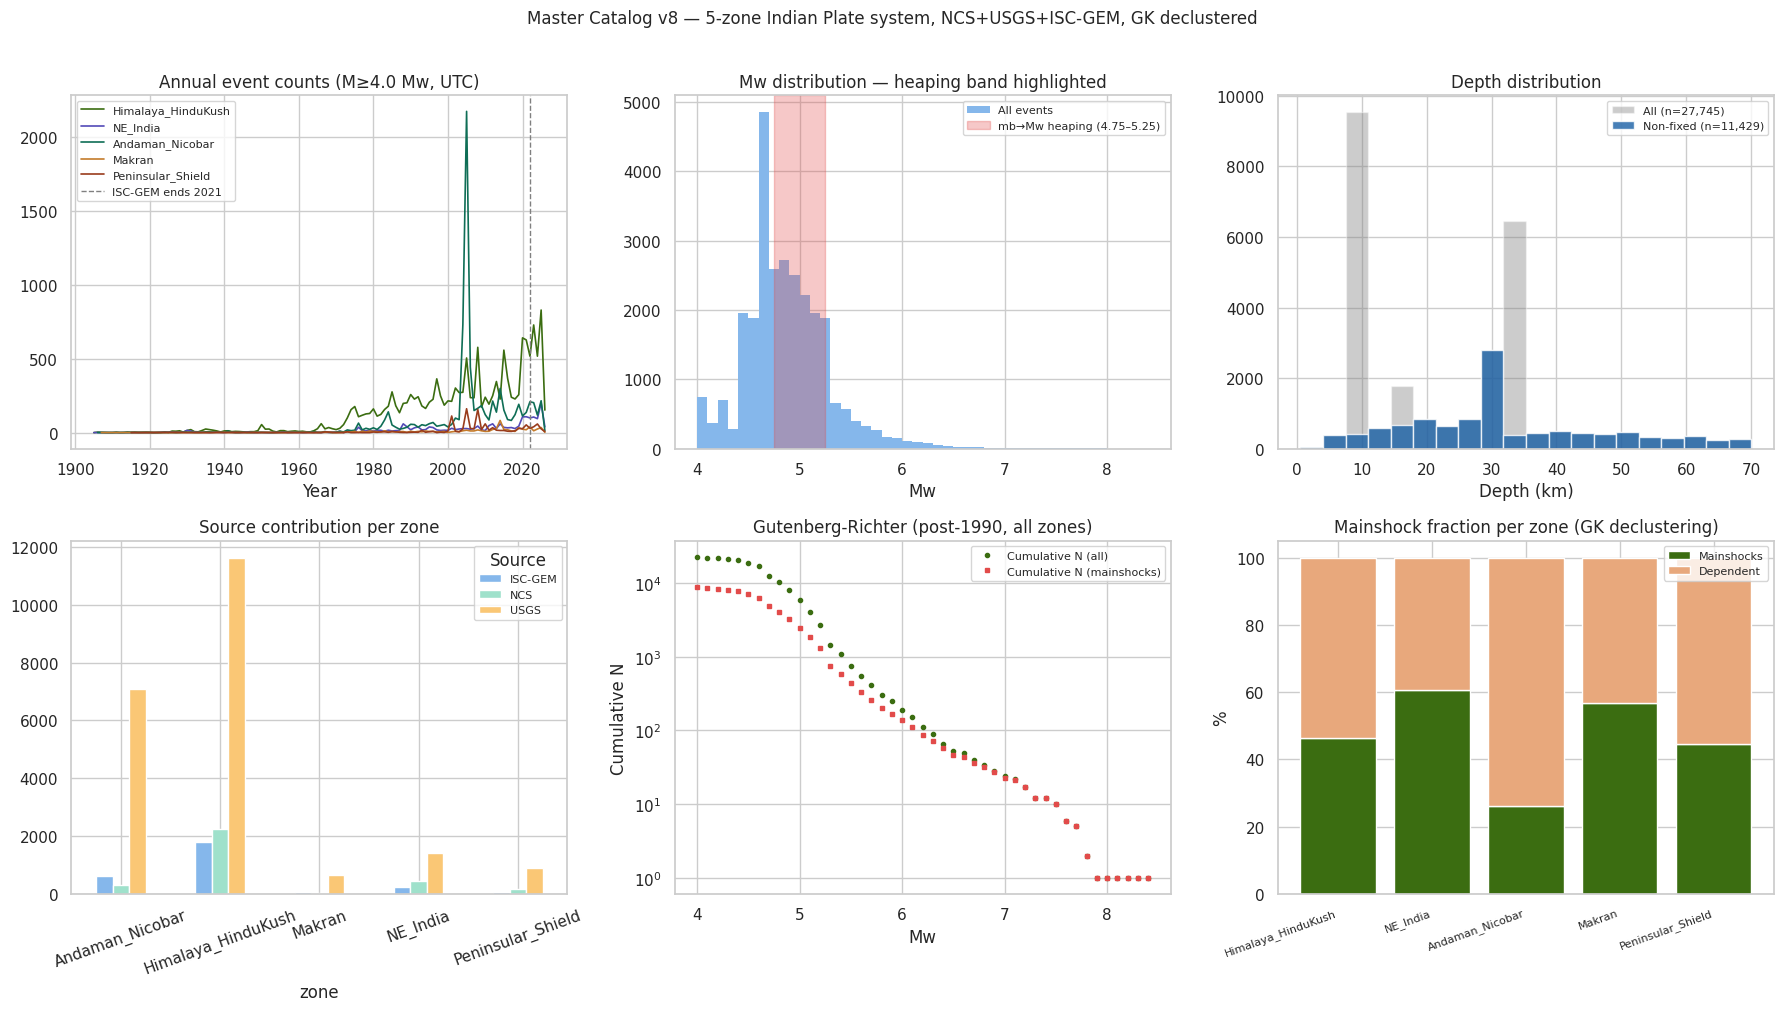

Saved: results_figures/catalog_diagnostic_v8.png


In [14]:
mzo = master_final.copy()
mzo['year'] = mzo['time'].dt.year

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Annual counts ─────────────────────────────────────────────────────────────
ax = axes[0, 0]
pal = {'Himalaya_HinduKush':'#3B6D11','NE_India':'#534AB7',
       'Andaman_Nicobar':'#0F6E56','Makran':'#C47B2B',
       'Peninsular_Shield':'#993C1D'}
for zone, color in pal.items():
    sub = mzo[mzo.zone == zone]
    ann = sub.groupby('year').size()
    ax.plot(ann.index, ann.values, label=zone, color=color, lw=1.2)
ax.axvline(2022, color='gray', ls='--', lw=1.0, label='ISC-GEM ends 2021')
ax.set_title('Annual event counts (M≥4.0 Mw, UTC)')
ax.set_xlabel('Year')
ax.legend(fontsize=8)

# ── Magnitude histogram ───────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(mzo.magnitude, bins=np.arange(4.0, 8.5, 0.1),
        color='#85B7EB', edgecolor='none', label='All events')
ax.axvspan(HEAPING_BAND_LO, HEAPING_BAND_HI,
           alpha=0.3, color='#E24B4A', label='mb→Mw heaping (4.75–5.25)')
ax.set_title('Mw distribution — heaping band highlighted')
ax.set_xlabel('Mw')
ax.legend(fontsize=8)

# ── Depth distribution ────────────────────────────────────────────────────────
ax = axes[0, 2]
real_d = mzo[~mzo.depth_fixed]
ax.hist(mzo.depth_km, bins=20, alpha=0.4,
        label=f'All (n={len(mzo):,})', color='gray')
ax.hist(real_d.depth_km, bins=20, alpha=0.8,
        label=f'Non-fixed (n={len(real_d):,})', color='#185FA5')
ax.set_title('Depth distribution')
ax.set_xlabel('Depth (km)')
ax.legend(fontsize=8)

# ── Source by zone ────────────────────────────────────────────────────────────
ax = axes[1, 0]
mzo.groupby(['zone','source']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#85B7EB','#9FE1CB','#FAC775'])
ax.set_title('Source contribution per zone')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Source', fontsize=8)

# ── Gutenberg-Richter plot (post-1990, all zones combined) ────────────────────
ax = axes[1, 1]
yr_col = mzo['time'].dt.year
post90_all = mzo[yr_col >= 1990]['magnitude']
bins_gr = np.arange(4.0, 8.5, 0.1)
counts_cum = np.array([(post90_all >= m).sum() for m in bins_gr])
valid = counts_cum > 0
ax.semilogy(bins_gr[valid], counts_cum[valid], 'o', ms=3,
            color='#3B6D11', label='Cumulative N (all)')
# Overlay mainshocks only
post90_main = mzo[(yr_col >= 1990) & mzo.is_mainshock]['magnitude']
counts_main = np.array([(post90_main >= m).sum() for m in bins_gr])
valid_m = counts_main > 0
ax.semilogy(bins_gr[valid_m], counts_main[valid_m], 's', ms=3,
            color='#E24B4A', label='Cumulative N (mainshocks)')
ax.set_title('Gutenberg-Richter (post-1990, all zones)')
ax.set_xlabel('Mw')
ax.set_ylabel('Cumulative N')
ax.legend(fontsize=8)

# ── Mainshock fraction per zone ───────────────────────────────────────────────
ax = axes[1, 2]
zones_plot  = ZONES
main_pct    = []
dep_pct     = []
for z in zones_plot:
    s = mzo[mzo.zone == z]
    nm = s['is_mainshock'].sum()
    main_pct.append(100 * nm / len(s))
    dep_pct.append(100 * (1 - nm / len(s)))
x = np.arange(len(zones_plot))
ax.bar(x, main_pct, color='#3B6D11', label='Mainshocks')
ax.bar(x, dep_pct,  bottom=main_pct, color='#E8A87C', label='Dependent')
ax.set_xticks(x)
ax.set_xticklabels(zones_plot, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('%')
ax.set_title('Mainshock fraction per zone (GK declustering)')
ax.legend(fontsize=8)

plt.suptitle('Master Catalog v8 — 5-zone Indian Plate system, NCS+USGS+ISC-GEM, GK declustered',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('results_figures/catalog_diagnostic_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results_figures/catalog_diagnostic_v8.png')
